<a href="https://colab.research.google.com/github/paddy960609/strava_stat_prediction/blob/main/strava_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Strava VO₂ Max Prediction

## Objective

This project predicts an athlete's VO₂ Max using historical Strava activity metrics such as activity count, calories burned, cadence, stride length, and other running statistics.

The goal is to demonstrate an end-to-end machine learning workflow for fitness analytics using Python and XGBoost.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

In [ ]:
# # 1. Import Libraries

from google.colab import drive
import os
import pandas as pd

# Mount Google Drive
drive.mount('/content/gdrive')

# Project directory
PROJECT_DIR = "/content/gdrive/MyDrive/strava_LastSixMonths"

os.chdir(PROJECT_DIR)


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Load all Strava exports

In [ ]:
from pathlib import Path

RAW_DIR = Path("data/raw")

for file in RAW_DIR.glob("*.csv"):
    print(file.name)

sum_distance.csv
total_ascent.csv
mean_run_cadence.csv
vo2_max.csv
mean_hr.csv
total_activity_time.csv
mean_stride_length.csv


In [ ]:
os.listdir()

['data']

In [ ]:
import os

print(os.path.exists("data/raw/mean_stride_length.csv"))

True


In [ ]:
from pathlib import Path

print((Path("data/raw") / "mean_stride_length.csv").resolve())

/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/mean_stride_length.csv


In [ ]:
# 2. Load Strava Data
df_mean_stride_length = pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/mean_stride_length.csv',skiprows=1)
df_total_activity_time = pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/total_activity_time.csv',skiprows=1)
df_VO2_max = pd.read_csv(
    "/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/vo2_max.csv",
    skiprows=1,
    usecols=[0, 2],
    names=["Month", "VO2_Max"],
    header=0
)

df_average_run_cadence= pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/mean_run_cadence.csv',skiprows=1)
df_sum_distance = pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/sum_distance.csv',skiprows=1)
df_total_ascent = pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/total_ascent.csv',skiprows=1)

df_mean_heartrate = pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/mean_hr.csv',skiprows=1)



# Data Cleanup
Currently the data set all have the month and the activity type column. Since all dataset has the common information, i've removed them from each dataset individually while updating what value means in each of them. All dataset will be combined afterwards.


In [ ]:
df_mean_stride_length = df_mean_stride_length.rename(columns={"Value": "Mean_Stride_Length(m)", "Unnamed: 0": "Month"})
df_mean_stride_length = df_mean_stride_length.drop(columns=['m'])
df_mean_stride_length["Month"] = pd.to_datetime(df_mean_stride_length["Month"])
print(df_mean_stride_length.head())


       Month  Mean_Stride_Length(m)
0 2025-08-01                   1.16
1 2025-09-01                   1.17
2 2025-10-01                   1.16
3 2025-11-01                   1.17
4 2025-12-01                   1.15


In [ ]:

df_total_activity_time = df_total_activity_time.rename(columns={"Value": "Activity_time(min)", "Unnamed: 0": "Month"})
df_total_activity_time = df_total_activity_time.drop(columns=['Activity Type'])
df_total_activity_time["Month"] = pd.to_datetime(df_total_activity_time["Month"], format="%b %Y")
df_total_activity_time.head()

,Month,Activity_time(min)
0,2025-08-01,920.86
1,2025-09-01,978.70
2,2025-10-01,745.44
3,2025-11-01,219.46
4,2025-12-01,304.39


In [ ]:
# df_VO2_max = (
#     df_VO2_max
#     .drop(columns="Unnamed: 0")
#     .reset_index()
#     .rename(columns={"index": "Month"})
# )

df_VO2_max["Month"] = pd.to_datetime(df_VO2_max["Month"], format="%b %Y")
df_VO2_max.head()

,Month,VO2_Max
0,2025-08-01,54.2
1,2025-09-01,54.6
2,2025-10-01,54.7
3,2025-11-01,54.5
4,2025-12-01,53.8


In [ ]:
# 3. Data Cleaning
# 4. Exploratory Data Analysis
# 5. Feature Engineering


df_average_run_cadence = df_average_run_cadence.rename(columns={"Value": "Average_Run_Cadence(spm)", "Unnamed: 0": "Month"})
df_average_run_cadence = df_average_run_cadence.drop(columns=['Run Cadence'])
df_average_run_cadence["Month"] = pd.to_datetime(df_average_run_cadence["Month"])
df_average_run_cadence.head()

,Month,Average_Run_Cadence(spm)
0,2025-08-01,147
1,2025-09-01,148
2,2025-10-01,153
3,2025-11-01,146
4,2025-12-01,152


total distance

In [ ]:
df_sum_distance = df_sum_distance.rename(columns={"Value": "Total_distance(mi)", "Unnamed: 0": "Month"})
df_sum_distance = df_sum_distance.drop(columns=['Activity Type'])
df_sum_distance["Month"] = pd.to_datetime(df_sum_distance["Month"])
df_sum_distance.head()


/tmp/ipykernel_1306/2273552375.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sum_distance["Month"] = pd.to_datetime(df_sum_distance["Month"])


,Month,Total_distance(mi)
0,2025-08-01,94.51
1,2025-09-01,103.81
2,2025-10-01,84.15
3,2025-11-01,23.24
4,2025-12-01,32.88


total ascent

In [ ]:
df_total_ascent = df_total_ascent.rename(columns={"Value": "Total_ascent(ft)", "Unnamed: 0": "Month"})
df_total_ascent = df_total_ascent.drop(columns=['Activity Type'])
df_total_ascent["Month"] = pd.to_datetime(df_total_ascent["Month"])
df_total_ascent.head()

/tmp/ipykernel_1306/423031384.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_total_ascent["Month"] = pd.to_datetime(df_total_ascent["Month"])


,Month,Total_ascent(ft)
0,2025-08-01,2952.755906
1,2025-09-01,3710.629921
2,2025-10-01,2765.748031
3,2025-11-01,925.196850
4,2025-12-01,1991.469816


In [ ]:
df_mean_heartrate = df_mean_heartrate.rename(columns={"Value": "Mean_Heart_Rate(bpm)", "Unnamed: 0": "Month"})
df_mean_heartrate  = df_mean_heartrate.drop(columns=['Heart Rate'])
df_mean_heartrate["Month"] = pd.to_datetime(df_mean_heartrate["Month"])
print(df_mean_heartrate.head())

       Month  Mean_Heart_Rate(bpm)
0 2025-08-01                   151
1 2025-09-01                   149
2 2025-10-01                   148
3 2025-11-01                   143
4 2025-12-01                   150


Each Strava export contains a different fitness metric.

These datasets are merged using activity date to create one comprehensive training dataset.

In [ ]:
# for i, df in enumerate(dfs):
#     print(f"DataFrame {i}")
#     print(df.columns)
#     print(df.dtypes)
#     print()
from functools import reduce

dfs = [
    df_mean_stride_length,
    df_total_activity_time,
    df_VO2_max,
    df_average_run_cadence,
    df_sum_distance,
    df_total_ascent,
    df_mean_heartrate
]

merged = reduce(
    lambda left, right: pd.merge(left, right, on="Month"),
    dfs
)
# combined_df = pd.concat([df_mean_stride_length, df_total_activity_time, df_VO2_max, df_average_run_cadence, df_sum_distance, df_total_ascent, df_mean_heartrate], axis=1)
# combined_df = combined_df.rename(columns={"Unnamed: 0": "Month"})
merged.info()
merged.describe()
merged.isnull().sum()
merged.head()
merged.to_csv("/content/gdrive/MyDrive/strava_LastSixMonths/data/processed/merged_strava_data.csv", index=False)
X = merged.drop(columns=["VO2_Max", "Month"])
y = merged["VO2_Max"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Month                     12 non-null     datetime64[ns]
 1   Mean_Stride_Length(m)     12 non-null     float64       
 2   Activity_time(min)        12 non-null     float64       
 3   VO2_Max                   12 non-null     float64       
 4   Average_Run_Cadence(spm)  12 non-null     int64         
 5   Total_distance(mi)        12 non-null     float64       
 6   Total_ascent(ft)          12 non-null     float64       
 7   Mean_Heart_Rate(bpm)      12 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 900.0 bytes


#Correlation heatmap

<Axes: >

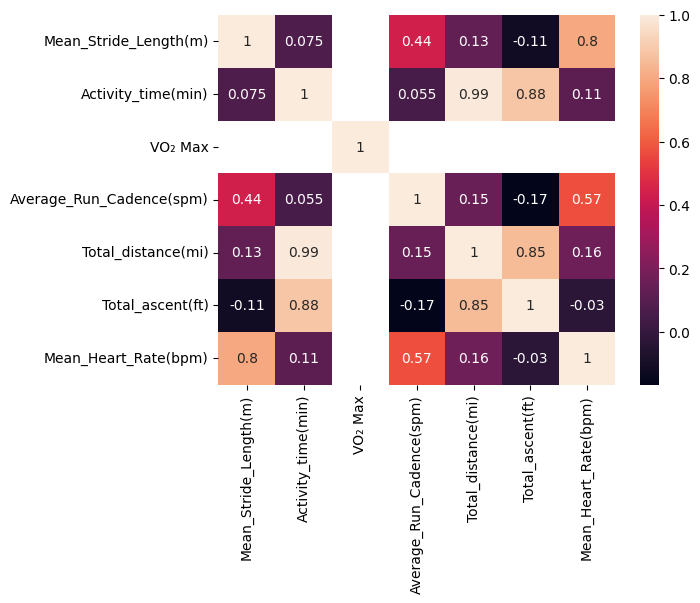

In [ ]:
sns.heatmap(combined_df.corr(), annot=True)


#VO₂ Max distribution

(array([3., 1., 0., 3., 0., 1., 0., 1., 1., 2.]),
 array([52.9 , 53.08, 53.26, 53.44, 53.62, 53.8 , 53.98, 54.16, 54.34,
        54.52, 54.7 ]),
 <BarContainer object of 10 artists>)

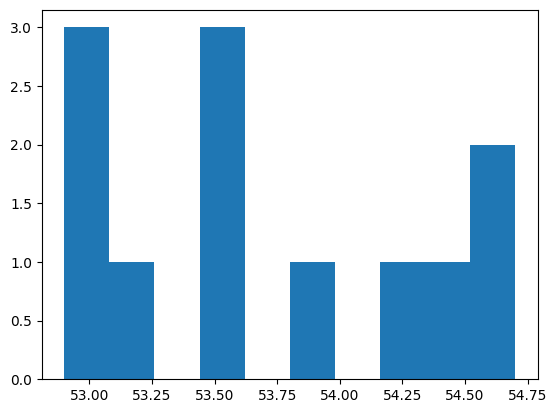

In [ ]:
plt.hist(combined_df["VO₂ Max"])

In [ ]:
# 6. Model Training

import numpy as np
from sklearn.model_selection import train_test_split
target_df = combined_df['VO₂ Max']
input_df = combined_df.drop(columns = ['VO₂ Max'])
X = np.array(input_df).astype('float32')
y = np.array(target_df).astype('float32')
# from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# X_train, X_temp, y_train, y_temp = train_test_split(
#     input_df.values, target_df.values, test_size=0.25, random_state=42
# )

# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42
# )


## Why XGBoost?

XGBoost was selected because it effectively models nonlinear relationships, handles feature interactions, and performs well on structured fitness data.

In [ ]:
# Train an XGBoost classifier model
!pip install xgboost

from xgboost import XGBRegressor, plot_importance
model = XGBRegressor(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42)
model.fit(X_train, y_train)
plot_importance(model)

XGBoostError: [20:31:11] /__w/xgboost/xgboost/src/data/data.cc:568: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2c69bc) [0x7af0d8ec69bc]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5b8b89) [0x7af0d91b8b89]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5b9b25) [0x7af0d91b9b25]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0x10b) [0x7af0d8dcf98b]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7af127716e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7af127713493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7af128a938c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x8ffe) [0x7af128a92ffe]
  [bt] (8) /usr/bin/python3(_PyObject_Mak

In [ ]:
result_train = model.score(X_train, y_train)
result_train

In [ ]:
y_predict = model.predict(X_test)

In [ ]:
# 7. Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_predict))
r2 = r2_score(y_test, y_predict)

In [ ]:
print(f"✅ Model Trained")
print(f"📈 RMSE: {rmse:.2f}")
print(f"📊 R² Score: {r2:.2f}")

In [ ]:
# import matplotlib.pyplot as plt

print("Train R²:", model.score(X_train, y_train))
print("Val R²:", model.score(X_val, y_val))
print("Test R²:", model.score(X_test, y_test))


actual vs predicted plot

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_predict, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted VO2 max")

In [ ]:
residuals = y_test - y_predict

plt.scatter(y_predict, residuals)

plt.axhline(y=0, color="red", linestyle="--")